# Discounts and Sales in Retail

**Mini-project — Programming & Data Analytics**

---

## Introduction

Retail companies often use discounts to try to increase sales. From a company perspective, discounts are an important tool to drive revenue and manage demand. However, it is not always clear how discounts and sales are related in practice, and whether discounts are associated with higher sales or mainly used when demand is already low. Indeed, several factors affect both variables at the same time. For example, higher discounts are often applied to products that are not selling well, which can create a negative association in the data. At the same time, discounts can also increase sales by making products more attractive. Therefore, the observed relationship can come from several mechanisms at the same time.

From a more personal perspective, I will soon start an internship at Procter & Gamble in the mass retail (FMCG) sector, where I will work on sales monitoring and promotion tracking. Analysing the link between discounts and sales is therefore a relevant and practical starting point and can serve as a basis for more advanced analyses (incl. other variables like the category, region...). With this in mind, let's see:

**What is the relationship between discounts and sales?**

The goal is to explore how sales vary with different discount levels, and whether we observe any clear pattern between the two variables.
To do this, we use the Superstore dataset, which contains around 10,000 retail transactions, including information on discounts, sales, and product categories. I found it particularly relevant because it lets us directly look at how promotional strategies are associated with sales performance.

The approach is intentionally simple. We first explore the dataset, then visualise the relationship between discounts and sales, and finally use a basic linear regression to quantify it.  

**Important clarifications**:  
(i) In this dataset, “Sales” refers to the revenue generated by each transaction (in dollars), not the number of units sold.  
(ii) In this project, we do not identify a causal effect. Discounts are not randomly assigned, so we only study a statistical relationship between discounts and sales in this dataset.

---

*Personal note:*  
*This project is my first experience with data analysis in Python. It was a useful learning step, and helped me better understand how data can support business decisions.*

## 1. Setup

We import the functions defined in `utils.py`.

The main steps (loading the data, cleaning it, plotting, and running the regression) are written in that file. In this notebook, we use these functions and focus on understanding and interpreting the results.

In [1]:
from utils import (
    load_data,
    clean_data,
    avg_sales_by_discount,
    plot_scatter,
    plot_avg_sales,
    run_regression,
    print_regression_summary,
)

%matplotlib inline

## Data overview

We start by loading the dataset and looking at its structure.
The dataset contains information about retail transactions, including sales, discounts, profit, and product categories.

In [2]:
# We load the raw dataset
df_raw = load_data("superstore.csv")

# We check the size of the dataset (rows, columns)
print("Shape:", df_raw.shape)

# We display the first 5 rows to see what it looks like
df_raw.head(5)

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


For this project, we focus mainly on two variables:
- **Sales**: the amount of money generated by a transaction
- **Discount**: the discount applied to the product (between 0 and 1)

We also keep **Profit** and **Category** for context, even if we do not use them directly in the model.

We choose to focus on Sales and Discount to keep the analysis simple. However, we should keep in mind that other variables (like category or region) could also affect sales.

In [3]:
# Therefore, we clean the dataset (keep relevant columns and drop missing values)
df = clean_data(df_raw)

# Then, we check the new shape after cleaning
print("Shape after cleaning:", df.shape)

# and finally, we display the cleaned data
df.head()

Shape after cleaning: (9994, 4)


,Sales,Discount,Profit,Category
0,261.9600,0.00,41.9136,Furniture
1,731.9400,0.00,219.5820,Furniture
2,14.6200,0.00,6.8714,Office Supplies
3,957.5775,0.45,-383.0310,Furniture
4,22.3680,0.20,2.5164,Office Supplies


In [4]:
# We now look at basic statistics for numerical variables
df.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,229.858001,0.156203,28.656896
std,623.245101,0.206452,234.260108
min,0.444000,0.000000,-6599.978000
25%,17.280000,0.000000,1.728750
50%,54.490000,0.200000,8.666500
75%,209.940000,0.200000,29.364000
max,22638.480000,0.800000,8399.976000


We can observe that sales are very dispersed, with a few very large values. The mean is much higher than the median, which suggests a right-skewed distribution (most transactions are relatively small, with a few very large values). On the other hand, discounts values range from 0 to 0.8, with an average around 0.15.

In [5]:
# We can go a bit further and check the different categories in the dataset 
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

As we can see, the dataset is not balanced across categories as most observations are in Office Supplies.  
And since sales and discount strategies may differ across categories, this could affect our results,

## 3. Exploratory analysis

Before running the regression, let's explore the data visually to explore how discounts and sales are related.  
We will proceed step by step, using simple questions to guide the analysis.

First, we look at how discounts are distributed in the dataset.    
- **Are most transactions discounted, or not?**

In [6]:
df["Discount"].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

We see that most transactions have either no discount or a 20% discount. Other discount levels are much less frequent.  
So the dataset is not evenly distributed across discount levels.

Next, we look directly at the relationship between discount and sales and check if:

- **Higher discounts seem to be associated with higher sales?**

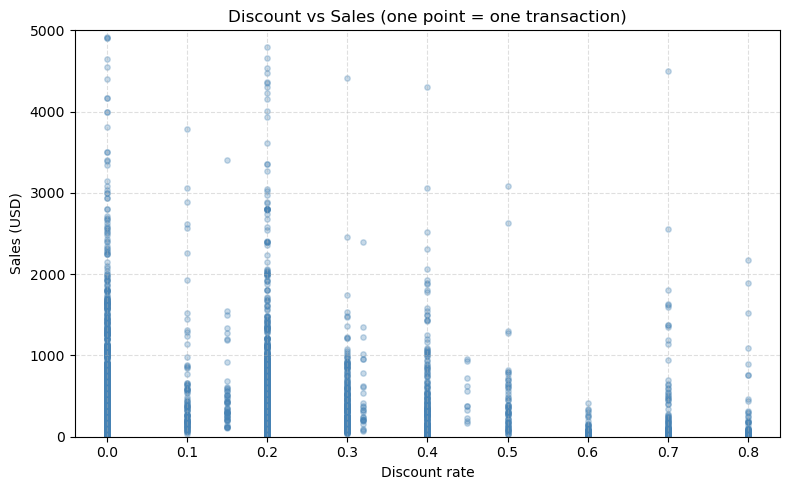

In [7]:
plot_scatter(df)

The scatter plot does not show a clear pattern between discount and sales. Indeed, we do not observe that higher discounts are associated with higher sales. If this was the case, we would expect to see larger sales values on the right side of the chart, but this is not clearly visible here. Hence we understand that the relationship looks quite weak in the superstore dataset.

To better understand this, we can now look at the average sales for each discount level.
- **Are average sales higher when discounts are higher?** 

In [8]:
avg_sales = avg_sales_by_discount(df)
print(avg_sales.round(2))

    Discount  avg_sales
0       0.00     226.74
1       0.10     578.40
2       0.15     529.97
3       0.20     209.08
4       0.30     454.74
5       0.32     536.79
6       0.40     565.13
7       0.45     498.63
8       0.50     892.71
9       0.60      48.15
10      0.70      97.18
11      0.80      56.55


Let's try making this a bit more visual.

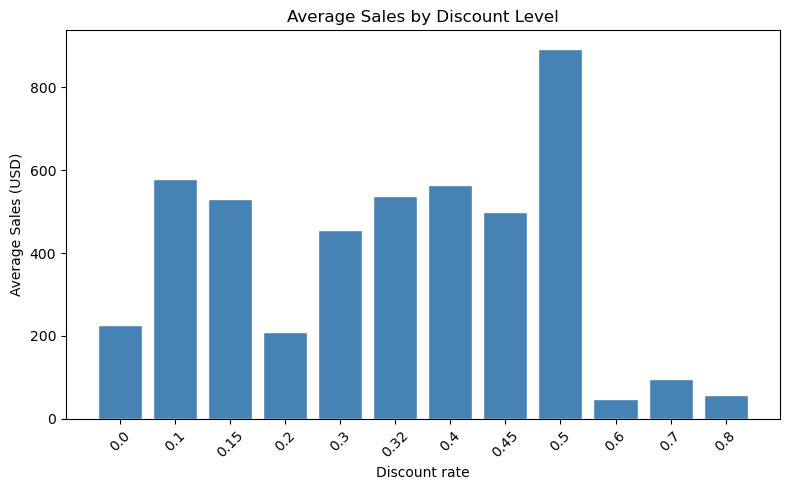

In [9]:
plot_avg_sales(avg_sales)

This is quite interesting. Looking at the bar chart, average sales are not systematically higher when discounts are bigger. In fact, some intermediate discount levels (like 10%, 15% or 50%) have relatively high average sales, while very high discounts (60%, 70%, 80%) are associated with lower average sales. 

Therefore, this does not look like a clear positive relationship. One possible explanation is that large discounts are often applied to cheap or slow-moving products (i.e. harder to sell), which naturally have lower sales values. In constrast, more expensive items (like bulk technology orders) might be sold with little or no discount at all.

That said, these are just averages and the sample sizes are very different across discount levels (4,800 transactions at 0% vs only 11 at 45%), so we should be careful not to read too much into this chart alone...

## 4. Regression Analysis

To go further, we run a simple OLS regression. The idea is to model the relationship between discount and sales with a straight line:

$$\text{Sales} = b_0 + b_1 \times \text{Discount} + \varepsilon$$

- $b_0$ is the expected average sales when the discount is 0
- $b_1$ tells us how much sales change, on average, when the discount increases by 1 (i.e. by 100 percentage points)
- $\varepsilon$ is the error term, which captures everything else that affects sales

The regression will give us a coefficient and a p-value to assess whether the relationship is statistically significant, and an R² to measure how strong it is.

In [10]:
results = run_regression(df)
print_regression_summary(results)

OLS regression: Sales ~ Discount
--------------------------------------
  Intercept  (b0) : 243.15
  Slope      (b1) : -85.10
  R-squared       : 0.0008
  p-value         : 0.0048
  Std error       : 30.19
--------------------------------------


## 5. Interpretation
**What do the coefficients tell us?**  
The intercept is around 243, so when the discount is 0, the model predicts average sales of about $243.  
We find it reassuring as this is quite close to the overall average we observed earlier.

Moreover, the slope is around -85, terefore when the discount increases, sales tend to decrease on average.  
And since discount goes from 0 to 1, a full increase (from 0% to 100%) would correspond to about -85 in sales.  
Consenquently, a 10% increase in discount is associated with a decrease of about 8 to 9 in sales.

So the relationship we estimate is negative.

**But, is this statistically significant?**  
Well, the p-value is around 0.005, which is below 0.05.  
Thus, the relationship we observe is unlikely to be due to random variation in the data.

**What about R²? is the relationship strong?**  
The R² is extremely low (around 0.001).  
Hence, discount explains almost none of the variation in sales. In other words, knowing the discount does not help much in predicting sales.  
So even if the relationship is statistically significant, it is very weak in practice.

This confirms what we observed in the plots before: there is no clear relationship between discount and sales.  
Indeed, the regression detects a relationship, but it is very weak and does not explain much.

**In short:** we find a statistically significant but very weak relationship between discount and sales, and discount alone is not a good predictor of sales in this dataset.
This means that higher discounts are associated with slightly lower sales on average, but this relationship is small and does not explain much of the variation in sales.

## 6. Conclusion

To answer our research question: discounts do influence sales, but not in the way we might expect. There is a relationship between discount and sales, but it is weak and negative. However, this does not necessarily mean that discounts are bad for business.This result is mainly due to an important **limitation** in our analysis, known as **endogeneity**. Discounts are not randomly assigned: in practice, larger discounts are often applied to cheaper or slow-moving products, which naturally have lower sales values. As a result, the negative relationship we observe likely reflects the type of products being discounted, rather than the actual effect of discounts on sales. So we can identify a statistical association between discount and sales, but we cannot conclude that discounts have a causal impact. Finally, we can conclude that the negative relationship we observe mainly comes from the structure of the data and not necessarily from the effect of discounts themselves.

If I had to continue this analysis, I would:
1. Control for product category, since discounting strategies are probably very different across Furniture, Technology and Office Supplies.
2. Look at quantity sold instead of revenue, since a discount might increase volume even if it reduces the dollar amount per transaction.
3. Use a better identification strategy, for ex. by comparing sales before and after a specific promotion campaign, to isolate the actual effect of discounting.